# Trying out training with a very simple model 

In [ ]:
# import pytorch
import torch

import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import ToTensor, Lambda
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt
import numpy as np

# custom code
import source.preprocessing as cheepre
import mypytorch_pixelseg.mymodels as mm
import mypytorch_pixelseg.dataset_classes as md
import mypytorch_pixelseg.mytrainer as mt


In [56]:
# reload if necessary
import importlib;
importlib.reload(cheepre)
importlib.reload(mm)
importlib.reload(md)
importlib.reload(mt)

<module 'mypytorch.mytrainer' from '/Users/m.wehrens/Documents/git_repos/_UVA/2025_Cheeky-cells/mypytorch/mytrainer.py'>

In [58]:
%%capture
ANNOT_DIR = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_humanannotated/'
IMG_DIR   = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_grey/'
mydataset = md.CustomImageDataset(annot_dir=ANNOT_DIR, 
                               img_dir=IMG_DIR, 
                               transform=ToTensor(), 
                               target_transform=Lambda(lambda y: torch.zeros(6, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)),
                               preload_imgs=True)

Dataset size:  494732


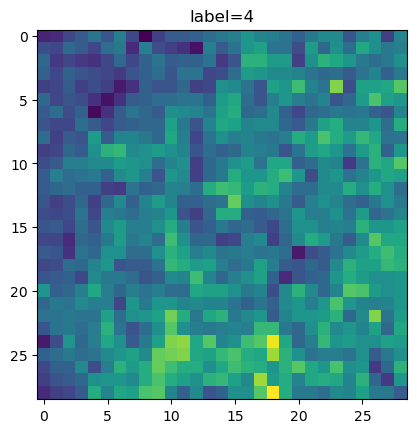

In [59]:
# show one of the images of "mydataset" above
image, label = mydataset[0]
plt.imshow(image.to("cpu")[0])
plt.title('label='+str(np.where(label.to("cpu"))[0][0]))
# also show size of "mydataset"
print('Dataset size: ', len(mydataset))

In [61]:
# divide mydataset into 20% test set and 80% training set

# Define the sizes of the splits
total_size = len(mydataset)
train_size = int(0.8 * total_size)  # 80% for training
val_size = total_size - train_size   # 20% for validation

# from torch.utils.data import random_split
# Create the splits (in case random sampling is needed)
# train_dataset, val_dataset = random_split(
#     mydataset, 
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(42)  # For reproducibility
# )

# Split the dataset manually, simply taking the first train_size samples
train_dataset = torch.utils.data.Subset(mydataset, range(train_size))
val_dataset = torch.utils.data.Subset(mydataset, range(train_size, total_size))

# Also subset the weights
train_weights  = mydataset.labels[:train_size]
val_weights    = mydataset.labels[train_size:total_size]


In [62]:
len(train_dataset)
len(val_dataset)

98947

In [ ]:
# Device a weighing scheme, that can be used for evenly distributed sampling
# get label distributions
# horribly slow:

# When weights weren't built in
# # faster:
# original_labels = mydataset.labels
# labels_trainset    = original_labels[train_dataset.indices]
# labels_valset      = original_labels[val_dataset.indices]

# # weights for training set
# train_bincounts = np.bincount(labels_trainset)
# class_weights_train = 1.0 / train_bincounts
# class_weights_train[train_bincounts==0] = 0 # counters div 0
# weights_train = class_weights_train[labels_trainset]  # Assign a weight to each sample
# # also for val_set
# val_bincounts = np.bincount(labels_valset)
# class_weights_val = 1.0 / val_bincounts
# class_weights_val[val_bincounts==0] = 0
# weights_val = class_weights_val[labels_valset]  # Assign a weight to each sample

# set samplers
sampler_train = WeightedRandomSampler(train_weights, num_samples=len(train_dataset), replacement=True)
sampler_val   = WeightedRandomSampler(val_weights, num_samples=len(val_dataset), replacement=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, 
                        sampler=sampler_train) # untested

generator = torch.Generator().manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=64, # shuffle=False, 
                        shuffle=False, generator=generator, # untested
                        sampler=sampler_val)

In [64]:
print(class_weights_val)
print(class_weights_train)

[0.00000000e+00 3.04534519e-05 3.18603243e-05 1.39082058e-04
 4.09115084e-05 3.23624595e-04]
[0.00000000e+00 7.58058158e-06 8.01455443e-06 3.47741419e-05
 1.02091862e-05 8.07232806e-05]


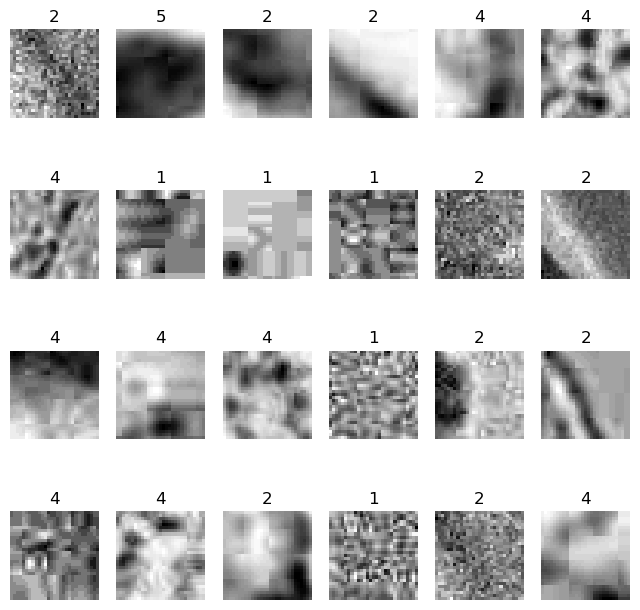

shape img torch.Size([1, 29, 29])


In [65]:
# Show images from the train_dsatset with labels
# train_dataset, val_dataset 

figure = plt.figure(figsize=(8, 8))
cols, rows = 6, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    img, label = img.to("cpu"), label.to("cpu")
    # convert label to default python int
    label_det = str(label.argmax().detach().cpu().numpy())
    figure.add_subplot(rows, cols, i)
    plt.title(   label_det   )
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

print('shape img', img.shape)
# ({int(label.detach().cpu().numpy())})


# Now define the model (CNN)

In [66]:
# get training device
device = "mps" if torch.backends.mps.is_available() else "cpu" # code is different from tutorial (fixed with co-pilot)
print(f"Using {device} device")

Using mps device


In [67]:
# initalize model and move to the correct device
modelCNN = mm.CNN((1, 29, 29),6).to(device)
print(modelCNN)

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=1600, out_features=6, bias=True)
)


In [68]:
# Load the model if desired
LOAD_MODEL = False
MODEL_PATH = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_90pct_2025-04-10_18-16.pth'

# Load the model
if LOAD_MODEL:
    modelCNN.load_state_dict(torch.load(MODEL_PATH))
    print(f"Model loaded from {MODEL_PATH}")

In [69]:
# We can now already call the model

X = torch.rand(1, 1, 29, 29, device=device) # random image as test input
logits = modelCNN(X) # "logits" refers to raw, unnormalized outputs of the final layer of a neural network
print('logits:', logits)
print('shape',logits.shape)
#pred_probab = nn.Softmax(dim=1)(logits) # converts output layer to probabilities
#print(f'Probabilities: {pred_probab}')
#y_pred = pred_probab.argmax(1) # finds the most likely label
#print(f"Predicted class: {y_pred}")

logits: tensor([[-0.0009, -0.1852,  0.0435,  0.2077, -0.0806,  0.1022]],
       device='mps:0', grad_fn=<LinearBackward0>)
shape torch.Size([1, 6])


In [70]:
# Same but for img loaded above
Xtestimg = img.to("mps").unsqueeze(0)
logits = modelCNN(Xtestimg) # "logits" refers to raw, unnormalized outputs of the final layer of a neural network
print('logits:', logits)
print('shape',logits.shape)
print('ground truth=',label)

Xtestimg.shape
# img.to(device).device

logits: tensor([[-0.0128, -0.1209,  0.0317,  0.1240, -0.0222,  0.0528]],
       device='mps:0', grad_fn=<LinearBackward0>)
shape torch.Size([1, 6])
ground truth= tensor([0., 0., 0., 0., 1., 0.])


torch.Size([1, 1, 29, 29])

# Now train the model

In [71]:
# Hyperparameters

# Hyperparameters are not parameters that define the model, but parameters that 
# relate to finding the solution;
    # - numbers of epochs: number of times to iterate over the whole dataset
    # - batch size: (PB) typically the loss of multiple instances is calculated in 
    #   paralellel; the loss is then determined as L(L1, L2, L3, L_batchsize), typically just
    #   sum. The backward propagation needs to be called from a single scalar
    #   tensor; So you simply define L = L1 + L2 + L3 + L_batchsize, the tensor 
    #   concept allows then backpropagation on L, implicitly taking all L_i into
    #   account.
    # - learning rate: how much to update models parameters at each batch/epoc;
        # I'm guessing this is some factor sets the size of W updates.

learning_rate = 1e-3 # 1e-3

# We need to set loss function, and optimizer
#loss_fn = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    # optimizer will actually implement some form of gradient descent
 
# From CNN   
loss_fn = torch.nn.CrossEntropyLoss()  # loss function
optimizer = torch.optim.Adam(modelCNN.parameters(), learning_rate)

    

In [72]:
# The training loop is custom coded

TOTAL_SAMPLES     = int(100_000)
TOTAL_TESTSAMPLES = int(10_000)
BATCH_SIZE        = 64
NUM_TESTBATCHES   = int(np.ceil(TOTAL_TESTSAMPLES/64))



In [73]:
# Now actually execute the training


# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=15, gamma=0.1) # step_size=10

epochs = 30 # 30
list_loss_tracker = []
list_correct = []
for t in range(epochs):
    
    print(f"Epoch {t+1}, LR: {scheduler.get_last_lr()}")
    
    # train and test
    loss_tracker = mt.train_loop(train_loader, modelCNN, loss_fn, optimizer, TOTAL_SAMPLES=TOTAL_SAMPLES, BATCH_SIZE=BATCH_SIZE)
    current_correct  = mt.test_loop(val_loader, modelCNN, loss_fn, NUM_TESTBATCHES=NUM_TESTBATCHES)
    
    # update scheduler
    scheduler.step()
    
    # track loss & test correctness
    list_loss_tracker.append(loss_tracker)    
    list_correct.append(current_correct)
    
print("Done!")

# estimated training time:
# 1 epoch + test = 31 sec
# 30 epochs --> ±15.5 mins

Epoch 1, LR: [0.001]
loss: 1.811176  [   64/100000]
loss: 1.146135  [ 6464/100000]
loss: 1.200400  [12864/100000]
loss: 1.115890  [19264/100000]
loss: 1.287920  [25664/100000]
loss: 1.158462  [32064/100000]
loss: 1.169527  [38464/100000]
loss: 1.054608  [44864/100000]
loss: 0.986858  [51264/100000]
loss: 0.998030  [57664/100000]
loss: 1.033372  [64064/100000]
loss: 1.139359  [70464/100000]
loss: 1.040959  [76864/100000]
loss: 1.086162  [83264/100000]
loss: 1.154306  [89664/100000]
loss: 0.912638  [96064/100000]
Epoch done
Predicting for test set.
Batch 0
Batch 25
Batch 50
Batch 75
Batch 100
Batch 125
Batch 150
Test Error: 
 Accuracy: 62.3%, Avg loss: 0.987884 

Epoch 2, LR: [0.001]
loss: 1.039306  [   64/100000]
loss: 0.904962  [ 6464/100000]
loss: 0.993632  [12864/100000]
loss: 0.879597  [19264/100000]
loss: 0.805001  [25664/100000]
loss: 0.884043  [32064/100000]
loss: 0.920872  [38464/100000]
loss: 0.958004  [44864/100000]
loss: 0.833591  [51264/100000]
loss: 1.032508  [57664/100000]

In [78]:
# Now save the model and its weights
# generate current date
import datetime
current_date = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
PATH = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_'+current_date+'.pth'
torch.save(modelCNN.state_dict(), PATH)

In [54]:
# import datetime
# datetime.datetime.now()
# .strftime("%Y-%m-%d_%H:%M")

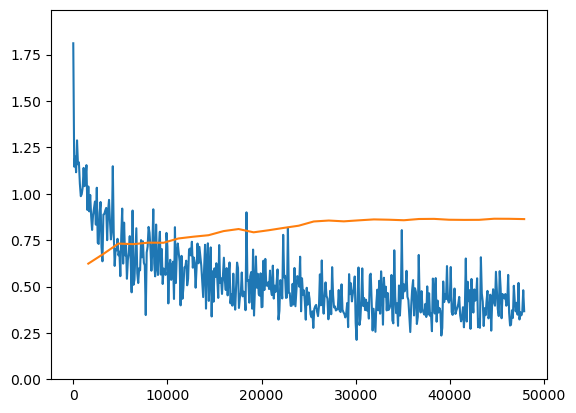

In [75]:
# Plot list_loss_tracker

import matplotlib.pyplot as plt
import numpy as np

datay = np.array(list_loss_tracker).flatten()
datax = np.array(range(len(datay)))*100
plt.plot(datax, datay)
plt.ylim([0, np.max(datay)*1.1])
datax[-1]

# and also plot the list_correct
data_correctx = np.linspace(datax[-1]/epochs, datax[-1], epochs)
data_correcty = np.array(list_correct)
plt.plot(data_correctx, data_correcty)


# Debugging

In [76]:
# load the model if desired (debugging purposes)

PATH='/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_CNN_90pct_2025-04-10_18-16.pth'
modelCNN = mm.CNN((1, 29, 29),6).to("mps")

modelCNN.load_state_dict(torch.load(PATH, weights_only=True))
modelCNN.eval()

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=1600, out_features=6, bias=True)
)

In [77]:
# Run an additional test loop for debugging..

loss_fn = torch.nn.CrossEntropyLoss()  # loss function
mt.test_loop(val_loader, modelCNN, loss_fn, NUM_TESTBATCHES=NUM_TESTBATCHES)

Predicting for test set.
Batch 0
Batch 25
Batch 50
Batch 75
Batch 100
Batch 125
Batch 150
Test Error: 
 Accuracy: 86.6%, Avg loss: 0.376258 



0.8655453821656051

In [36]:
# get one sample from the dataloader val_loader
(X, y) = next(iter(val_loader))
X.dtype
X.max()


tensor(0.8549, device='mps:0')

In [33]:
# I can also simply load the 50 first test set images
mydataset[:50]

TypeError: only integer scalar arrays can be converted to a scalar index